<a href="https://colab.research.google.com/github/Sakeena01/AI-Assisted-Threat-Detection-Dashboard/blob/main/python_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Create a basic pandas DataFrame from scratch with 3 columns: Name, Age, and City.

In [ ]:
import pandas as pd

data = {
    "Name": ["Alice", "Bob", "Charlie", "Diana"],
    "Age": [25, 30, 35, 28],
    "City": ["New York", "Los Angeles", "Chicago", "Houston"]
}

df = pd.DataFrame(data)

print(df)


      Name  Age         City
0    Alice   25     New York
1      Bob   30  Los Angeles
2  Charlie   35      Chicago
3    Diana   28      Houston


2. Show me how to load a CSV file into a pandas DataFrame and display the first 5 rows.

In [ ]:
import pandas as pd

df = pd.read_csv("sample.csv")   # replace "sample.csv" with your file path

print(df.head())


  CategoryColumn  NumericColumn
0              A           10.0
1              B           20.0
2              A            NaN
3              C           30.0
4              B            NaN


3. Write a complete Python script using scikit-learn to train a Random Forest Classifier. Use a built-in dataset like Iris or Wine, split it 80/20 into train/test sets, scale the features using StandardScaler, train the model, and print a classification report along with a confusion matrix heatmap using seaborn.*italicized text*

📊 Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



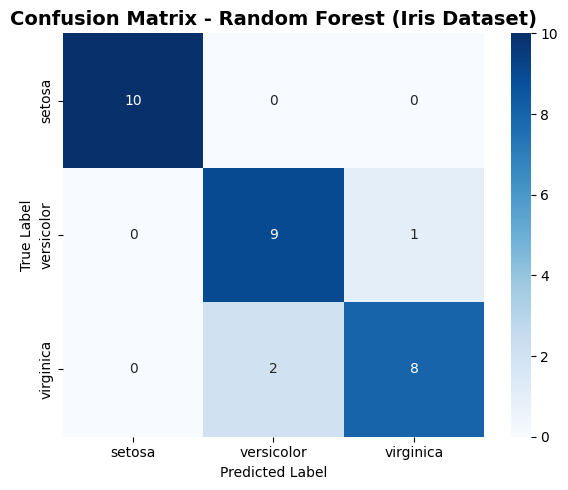

In [ ]:
!pip install -q scikit-learn seaborn matplotlib pandas

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris  # or load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

data = load_iris()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)

print("📊 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=target_names))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix - Random Forest (Iris Dataset)", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


4. Write a Python script using pandas and matplotlib to load a sample CSV file, clean missing values by replacing them with the column mean, group the data by a categorical column, calculate the average of a numeric column, and plot the result as a styled horizontal bar chart.

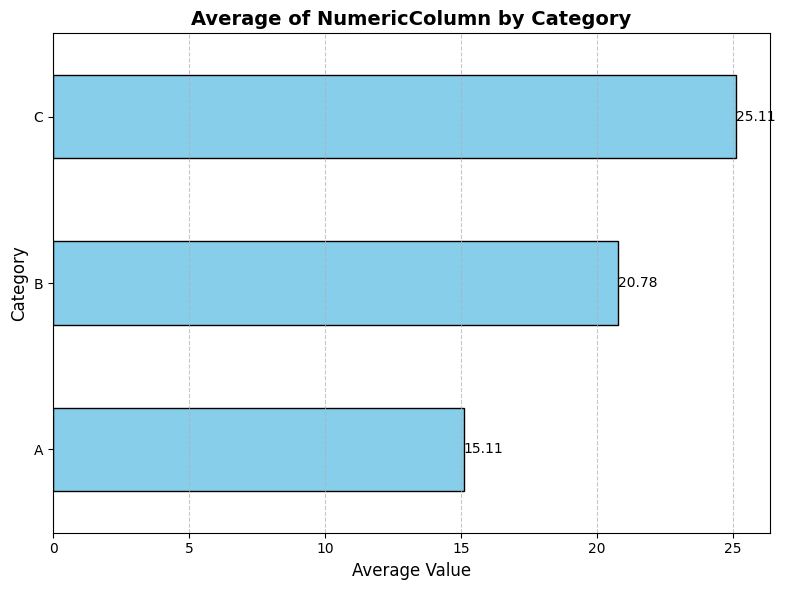

In [ ]:
!pip install -q scikit-learn seaborn matplotlib pandas

import pandas as pd
import matplotlib.pyplot as plt

data = {
    "CategoryColumn": ["A", "B", "A", "C", "B", "C", "A", "B", "C"],
    "NumericColumn": [10, 20, None, 30, None, 25, 15, 22, None]
}
df_sample = pd.DataFrame(data)
df_sample.to_csv("sample.csv", index=False)

df = pd.read_csv("sample.csv")

df.fillna(df.mean(numeric_only=True), inplace=True)

grouped = df.groupby("CategoryColumn")["NumericColumn"].mean().sort_values()

plt.figure(figsize=(8, 6))
grouped.plot(kind="barh", color="skyblue", edgecolor="black")

plt.title("Average of NumericColumn by Category", fontsize=14, fontweight="bold")
plt.xlabel("Average Value", fontsize=12)
plt.ylabel("Category", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.7)

for index, value in enumerate(grouped):
    plt.text(value, index, f"{value:.2f}", va="center", ha="left", fontsize=10)

plt.tight_layout()
plt.show()


5. Loop through the raw order dataset to manually calculate the total amount spent by each unique customer without using any libraries.

In [2]:
orders_data = [
    {'order_id': 1, 'customer_name': 'John Doe', 'category': 'Electronics', 'order_amount': 1200.50},
    {'order_id': 2, 'customer_name': 'Jane Smith', 'category': 'Furniture', 'order_amount': 450.00},
    {'order_id': 3, 'customer_name': 'Rahul Kumar', 'category': 'Electronics', 'order_amount': 85.00},
    {'order_id': 4, 'customer_name': 'Anna Miller', 'category': 'Apparel', 'order_amount': 45.25},
    {'order_id': 5, 'customer_name': 'John Doe', 'category': 'Apparel', 'order_amount': 120.00},
    {'order_id': 6, 'customer_name': 'Carlos Ruiz', 'category': 'Furniture', 'order_amount': 899.00},
    {'order_id': 7, 'customer_name': 'Jane Smith', 'category': 'Electronics', 'order_amount': 60.00},
    {'order_id': 8, 'customer_name': 'Rahul Kumar', 'category': 'Apparel', 'order_amount': 35.00}
]

customer_spending = {}

for order in orders_data:
    name = order['customer_name']
    amount = order['order_amount']

    if name in customer_spending:
        customer_spending[name] += amount
    else:
        customer_spending[name] = amount

print("--- Customer Total Spending (Using Loops) ---")
for customer, total in customer_spending.items():
    print(f"{customer}: ${total:.2f}")


--- Customer Total Spending (Using Loops) ---
John Doe: $1320.50
Jane Smith: $510.00
Rahul Kumar: $120.00
Anna Miller: $45.25
Carlos Ruiz: $899.00


6. Iterate through orders to filter out high-value purchases (> $100) and automatically calculate a 12% logistics tax using conditional loop logic.

In [3]:
print("--- High-Value Orders with 12% Logistics Tax ---")

for order in orders_data:
    if order['order_amount'] > 100.00:
        tax = order['order_amount'] * 0.12
        total_with_tax = order['order_amount'] + tax
        print(f"Order #{order['order_id']} ({order['customer_name']}): "
              f"Base: ${order['order_amount']} | Tax: ${tax:.2f} | Total: ${total_with_tax:.2f}")


--- High-Value Orders with 12% Logistics Tax ---
Order #1 (John Doe): Base: $1200.5 | Tax: $144.06 | Total: $1344.56
Order #2 (Jane Smith): Base: $450.0 | Tax: $54.00 | Total: $504.00
Order #5 (John Doe): Base: $120.0 | Tax: $14.40 | Total: $134.40
Order #6 (Carlos Ruiz): Base: $899.0 | Tax: $107.88 | Total: $1006.88


7. Train a Linear Regression model to predict the monetary value of an order based on historic purchase sequence/trends.

In [4]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np

X = np.array([[1], [2], [3], [4], [5], [6], [7], [8]])
y = np.array([1200.50, 450.00, 85.00, 45.25, 120.00, 899.00, 60.00, 35.00])

model = LinearRegression()
model.fit(X, y)

future_orders = np.array([[9], [10]])
predictions = model.predict(future_orders)

print("--- ML Order Amount Predictions ---")
print(f"Predicted value for Order #9: ${predictions[0]:.2f}")
print(f"Predicted value for Order #10: ${predictions[1]:.2f}")


--- ML Order Amount Predictions ---
Predicted value for Order #9: $-44.86
Predicted value for Order #10: $-135.24


8. Group clients into mathematical behavioral clusters using K-Means based on their spending volume to target VIP accounts.

In [7]:
from sklearn.cluster import KMeans
import pandas as pd

data = {
    'total_spent': [1320.50, 510.00, 120.00, 45.25, 899.00],
    'order_count': [2, 2, 2, 1, 1]
}
df_ml = pd.DataFrame(data)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df_ml['cluster_id'] = kmeans.fit_predict(df_ml[['total_spent', 'order_count']])

print(df_ml)


   total_spent  order_count  cluster_id
0      1320.50            2           1
1       510.00            2           0
2       120.00            2           0
3        45.25            1           0
4       899.00            1           1


9. Generate a continuous line graph using Matplotlib to map out chronological order amounts and visually track revenue fluctuations over time

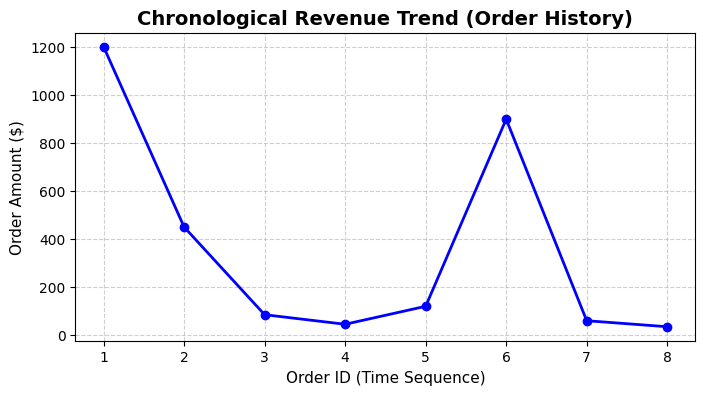

In [6]:
import matplotlib.pyplot as plt

order_ids = [1, 2, 3, 4, 5, 6, 7, 8]
order_amounts = [1200.50, 450.00, 85.00, 45.25, 120.00, 899.00, 60.00, 35.00]

plt.figure(figsize=(8, 4))
plt.plot(order_ids, order_amounts, marker='o', color='b', linestyle='-', linewidth=2)

plt.title('Chronological Revenue Trend (Order History)', fontsize=14, fontweight='bold')
plt.xlabel('Order ID (Time Sequence)', fontsize=11)
plt.ylabel('Order Amount ($)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


10. Construct a 2D scatter plot using Seaborn to visually segment high-value corporate spenders from low-frequency retail accounts based on K-Means outputs.

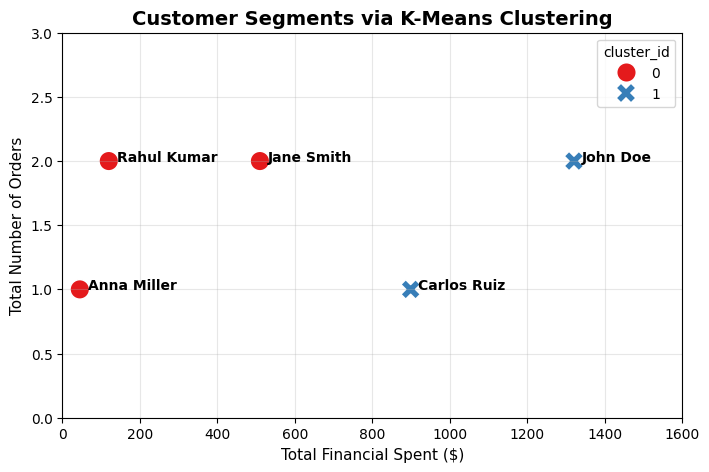

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


customer_data = {
    'customer': ['John Doe', 'Jane Smith', 'Rahul Kumar', 'Anna Miller', 'Carlos Ruiz'],
    'total_spent': [1320.50, 510.00, 120.00, 45.25, 899.00],
    'order_count': [2, 2, 2, 1, 1]
}
df_cluster = pd.DataFrame(customer_data)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df_cluster['cluster_id'] = kmeans.fit_predict(df_cluster[['total_spent', 'order_count']])

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_cluster,
    x='total_spent',
    y='order_count',
    hue='cluster_id',
    palette='Set1',
    s=200,
    style='cluster_id'
)

for i in range(df_cluster.shape[0]):
    plt.text(
        x=df_cluster.total_spent[i] + 20,
        y=df_cluster.order_count[i],
        s=df_cluster.customer[i],
        fontweight='semibold'
    )

plt.title('Customer Segments via K-Means Clustering', fontsize=14, fontweight='bold')
plt.xlabel('Total Financial Spent ($)', fontsize=11)
plt.ylabel('Total Number of Orders', fontsize=11)
plt.xlim(0, 1600)
plt.ylim(0, 3)
plt.grid(True, alpha=0.3)

plt.show()
